# MARKET BASKET ANALYSIS
- Planteamos la siguiente hipotesis de preguntas a resolver:
1. Que items son comprados con mayor frecuencia juntos.
2. Que item es comprado con mayor frecuencia como producto unico.
3. Que oportunidades existe de impulsar una venta cruzada/venta adicional
4. *anything other insights that might help the business (especially the types of findings included typically as part of market basket analysis)*

In [1]:
# principales librerias a trabajar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


## 1. Procesamiento de Datos

In [2]:
# the database is in the form of a csv file, so we will use pandas to read it
df = pd.read_csv("Analytics case study (market basket analysis ecommerce).csv")
df.head()


,Product,Product Category (Enhanced Ecommerce),Transaction ID,Unique Purchases,Product Revenue
0,3.7V 3400mah LIION 12.6WH,Battery/Consumer Rechargeable,EC0043605902,47,"$1,597.53"
1,3V PHOTO LITHIUM,Battery/Primary Other,EC0043507670,47,"$1,246.44"
2,12V 11.2AH 225CCA AGM 12/0,Battery/Powersports,EC0043504182,41,"$4,714.59"
3,12V 12AH 165CCA FLOODED 6/0,Battery/Powersports,EC0043503186,39,"$2,456.61"
4,12V 12AH 210CCA AGM 12/0,Battery/Powersports,EC0043406547,34,"$3,570.00"


In [3]:
# revisamos la composion de la base de datos
# vemos que hay 92250 filas y 5 columnas, y que no hay valores nulos
# observamos el tipo de datos de cada columna y que esta correponda con el tipo de dato que se espera
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92250 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Product                                92250 non-null  str  
 1   Product Category (Enhanced Ecommerce)  92250 non-null  str  
 2   Transaction ID                         92250 non-null  str  
 3   Unique Purchases                       92250 non-null  int64
 4   Product Revenue                        92250 non-null  str  
dtypes: int64(1), str(4)
memory usage: 9.0 MB


In [4]:
# revisamos si existen filas duplicadas. 
df.duplicated().sum()

np.int64(0)

In [5]:
# convertimos encabezado a minusculas y cambiamos nombre de columna product category a product_category para evitar problemas de formato.
df.columns = df.columns.str.lower()
df = df.rename(columns={'product category (enhanced ecommerce)': 'product_category'})
df.head()


,product,product_category,transaction id,unique purchases,product revenue
0,3.7V 3400mah LIION 12.6WH,Battery/Consumer Rechargeable,EC0043605902,47,"$1,597.53"
1,3V PHOTO LITHIUM,Battery/Primary Other,EC0043507670,47,"$1,246.44"
2,12V 11.2AH 225CCA AGM 12/0,Battery/Powersports,EC0043504182,41,"$4,714.59"
3,12V 12AH 165CCA FLOODED 6/0,Battery/Powersports,EC0043503186,39,"$2,456.61"
4,12V 12AH 210CCA AGM 12/0,Battery/Powersports,EC0043406547,34,"$3,570.00"


In [6]:
# convermios las filas de  la columna product y product category a minusculas para evitar problemas de formato.
df["product"] = df["product"].str.lower()
df["product_category"] = df["product_category"].str.lower()
df.head()

,product,product_category,transaction id,unique purchases,product revenue
0,3.7v 3400mah liion 12.6wh,battery/consumer rechargeable,EC0043605902,47,"$1,597.53"
1,3v photo lithium,battery/primary other,EC0043507670,47,"$1,246.44"
2,12v 11.2ah 225cca agm 12/0,battery/powersports,EC0043504182,41,"$4,714.59"
3,12v 12ah 165cca flooded 6/0,battery/powersports,EC0043503186,39,"$2,456.61"
4,12v 12ah 210cca agm 12/0,battery/powersports,EC0043406547,34,"$3,570.00"


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 92250 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   product           92250 non-null  str  
 1   product_category  92250 non-null  str  
 2   transaction id    92250 non-null  str  
 3   unique purchases  92250 non-null  int64
 4   product revenue   92250 non-null  str  
dtypes: int64(1), str(4)
memory usage: 9.0 MB


In [8]:
# 1. se convierte la columna product revenue a tipo string, se eliminan los simbolos de dolar y las comas, y se convierte a tipo float para poder realizar operaciones matematicas con esta columna.
df['product revenue'] = df['product revenue'].str.replace('$', '').astype('string')
df['product revenue'] = df['product revenue'].str.replace(',', '').astype('float')


## 2. EDA

In [9]:
# se verifica el tipo de datos de cada columna. 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92250 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product           92250 non-null  str    
 1   product_category  92250 non-null  str    
 2   transaction id    92250 non-null  str    
 3   unique purchases  92250 non-null  int64  
 4   product revenue   92250 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 8.4 MB


In [10]:
# principales estadisticas descriptivas de la base de datos
df.describe()

,unique purchases,product revenue
count,92250.000000,92250.000000
mean,1.164564,190.383006
std,0.676474,297.407428
min,1.000000,0.000000
25%,1.000000,44.990000
50%,1.000000,116.990000
75%,1.000000,219.980000
max,47.000000,14739.200000


En la columna unique purchases, que contiene la cantidad de productos comprados por un producto en particular, con un promedio de 1.67, lo que nos indica que un producto en particular en promedio se compra menos de 2 veces en una transaccion. Sin embargo encontramos productos con una cantidad de veces comprado a 47. 

En la columna product revenue, encontramos que en promedio un producto vale 297 usd. pero tambien encontramos productos de un valor de compra de 14739 usd. Vale la pena revisar a que categoria pertenecen estos producto y con que frecuencia se compran. 

Para ambas columnas encontramos una desviacion estandar de 0.67 y 297 respectivamente, lo que concluimos que el precio de los productos y la cantidad de compra de estos se encuentran en un rango cercano a su promedio. 

In [11]:
df.head()

,product,product_category,transaction id,unique purchases,product revenue
0,3.7v 3400mah liion 12.6wh,battery/consumer rechargeable,EC0043605902,47,1597.53
1,3v photo lithium,battery/primary other,EC0043507670,47,1246.44
2,12v 11.2ah 225cca agm 12/0,battery/powersports,EC0043504182,41,4714.59
3,12v 12ah 165cca flooded 6/0,battery/powersports,EC0043503186,39,2456.61
4,12v 12ah 210cca agm 12/0,battery/powersports,EC0043406547,34,3570.00


In [12]:
# se ordena los 10 poductos mas vendidos
df['product'].value_counts().head(10)

product
12v u1 l&amp;g 6                  2425
6v gc2 ultra golf 12              1684
agm 12v 7ah .187 faston           1642
12v 18ah 310cca agm 12/0          1204
12v 31dt duracell ultra agm 30    1118
agm 12v 5ah .187 faston           1077
dc 12v 35ah j term                1005
12v 17.5ah 310 cca                 996
1.5v ind aa alk bulk               979
1.5v alkal                         977
Name: count, dtype: int64

Text(0.5, 0, 'Producto')

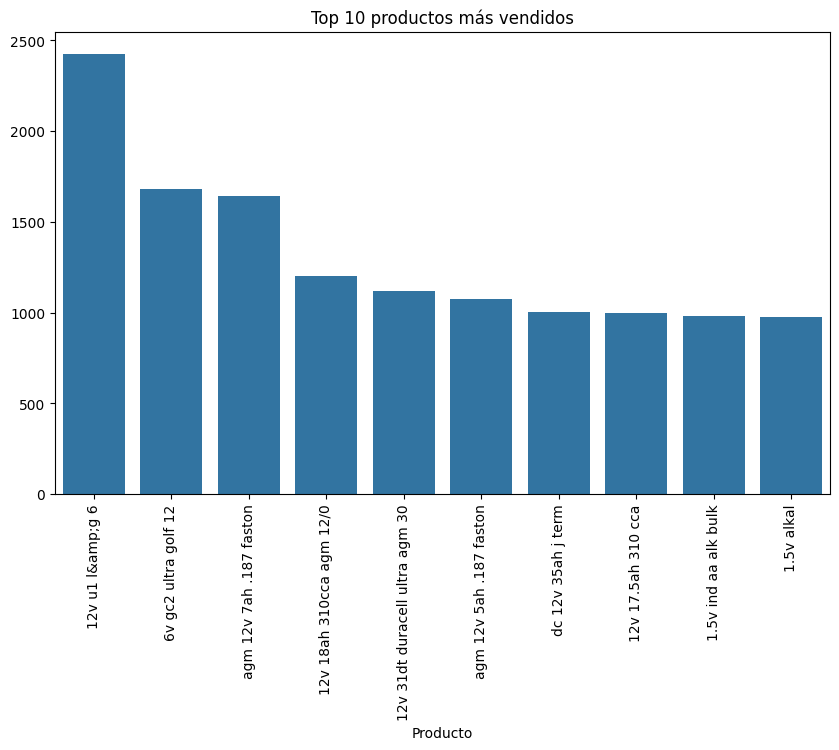

In [13]:
# grafica de los 10 productos mas vendidos
plt.figure(figsize=(10, 6))
sns.barplot(x=df['product'].value_counts().head(10).index, y=df['product'].value_counts().head(10).values)
plt.xticks(rotation=90)
plt.title('Top 10 productos más vendidos')
plt.xlabel('Producto')

## 3. Preparacion de los Datos

1. Agrupamos las columnas 'transaction id , product' y sumamos la cantidad de productos unicos comprados por transaccion.

2. Ordenamos y agrupamos la cantidad de items q aparecen por transaccion, agregamos la columna cantidad items para saber que cantidad de productos aparecen por transaccion. 

In [14]:
# se agrupan los productos por transaccion id y cantidad de compra unica por transaccion. 
productos_por_transaccion = df.groupby(['transaction id','product'])['unique purchases'].sum().reset_index().set_index('transaction id').sort_values(by='unique purchases', ascending = False)
productos_por_transaccion.head()


,product,unique purchases
transaction id,,
EC0043507670,3v photo lithium,47
EC0043605902,3.7v 3400mah liion 12.6wh,47
EC0043504182,12v 11.2ah 225cca agm 12/0,41
EC0043503186,12v 12ah 165cca flooded 6/0,39
EC0043406547,12v 12ah 220cca agm,34


La tabla anterior nos muestra la cantidad de productos que se compraron por transaccion. Sin embargo lo que buscamos es que productos fueron comprados en conjunto, para esto usamos el algoritmo apriori.

In [15]:
conjunto_productos = df.groupby('transaction id')['product'].apply(list).reset_index().set_index('transaction id')
conjunto_productos

,product
transaction id,
1234,[(not set)]
123456,[(not set)]
12345678,[(not set)]
<transaction id>,[<product name>]
EC0032704676,"[3v lithium cr2032 bulk, inspector pocket ligh..."
...,...
EC0044007291,[1.5v alkal]
EC0044007292,[d alkaline bulk]
EC0044007293,[12v 31 agm 48]


In [16]:
# eliminamos columna donde transaction id esta incompleto.
df.drop(df[df['transaction id'] == '<transaction id>'].index, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 92249 entries, 0 to 92249
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product           92249 non-null  str    
 1   product_category  92249 non-null  str    
 2   transaction id    92249 non-null  str    
 3   unique purchases  92249 non-null  int64  
 4   product revenue   92249 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 9.1 MB


In [17]:
# ordenamos la cantidad de productos que aparecen por transaccion.
conjunto_productos['cantidad_items'] = conjunto_productos['product'].apply(len)
conjunto_productos = conjunto_productos.sort_values(by='cantidad_items', ascending=False)

conjunto_productos

,product,cantidad_items
transaction id,,
EC0043604442,"[12v 65 ultra 24, 12v 24 ultra gold 36, 12v 24...",37
EC0043909841,"[1.2v 1200mah nimh, 1.2v 2700mah nimh, 1.2v 60...",30
EC0043101877,"[3v lithi, 1.5v lithi, 12v 26 ultra 24, 12v 35...",25
EC0043108851,"[12v 10ah 180cca agm, 12v 21ah 350cca agm 12/0...",16
EC0044006964,"[6v gc2 ultra golf 12, 12v 12ah 205cca agm 12/...",15
...,...,...
EC0043208091,[agm 12v 35ah (u1) cu ins],1
EC0043208090,[12v 24m marine 12],1
EC0043208089,[2pk 3v lithium coin],1


### 3.1 Aplicacion Transaction Encoder
La aplicacion de transaction encoder toma la lista de transacciones y la transforma en una matriz binaria. donde : 

1. cada producto se convierte en una columna independiente

2. Si el producto de esa columna fue comprado en la transaccion, le asigna un valor de 1; si no se compró, le asigna 0

In [18]:
# aplicamos TransactionEncoder para tener una matriz binaria 
te = TransactionEncoder()
te

TransactionEncoder()

In [19]:
# convertimos el dataset en una matriz binaria. donde 1 nos indica que el producto fue comprado dentro de esa transaccion y 0 que no hubo compra. 
te_array = te.fit_transform(conjunto_productos['product'])
te_df = pd.DataFrame(te_array, columns=te.columns_).astype(int)
te_df.index = conjunto_productos.index
te_df

,(4)f32t8 centium is unv,(not set),1 bank 10a onboard battery charger,1 bank 5a onboard battery charger,1.2v 1100mah nicad,1.2v 12000mah nimh,1.2v 1200mah nicad,1.2v 1200mah nicad 4/5a,1.2v 1200mah nimh,1.2v 1400mah nicad 4/5a,...,y50-n18l-a w/metal jacket,yb16l-b w/metal jacket,yeti 1500x portable power station,yeti 200x portable power,yeti 3000x portable power station,yeti 400 protection case,yeti 500x portable power station,zbug lantern + light,zus smart vehicle health monitor mini,zus universal car audio adapter
transaction id,,,,,,,,,,,,,,,,,,,,,
EC0043604442,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0043909841,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
EC0043101877,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0043108851,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0044006964,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC0043208091,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0043208090,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EC0043208089,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# 1. Sumamos las filas de la matriz binaria para saber cuántos productos hay por transacción
cantidad_por_factura = te_df.sum(axis=1)
# 2. Conservamos solo las filas de la matriz de 0 y 1 que tengan 2 o más productos
te_df_filtro = te_df[cantidad_por_factura >= 2]

print(f"Matriz original: {te_df.shape}")
print(f"Matriz filtrada (solo canastas reales): {te_df_filtro.shape}")


Matriz original: (83014, 2412)
Matriz filtrada (solo canastas reales): (6321, 2412)


### 3.2  Filtramos por transaccion(productos comprados mas de 1 vez)

El proposito de el analisis de market basket es descubrir la asociacion que existe entre 2 o mas productos comprados.

Identificar Productos que son comprados como unicos son menos utiles para campañas donde queremos impulsar la compra de productos y en camapañas de atraccion de clientes. 

In [21]:
# filtramos las transacciones con productos con mas de 1 item comprado.
conjunto_productos_filtro = conjunto_productos[conjunto_productos['cantidad_items'] >= 2]
conjunto_productos_filtro


,product,cantidad_items
transaction id,,
EC0043604442,"[12v 65 ultra 24, 12v 24 ultra gold 36, 12v 24...",37
EC0043909841,"[1.2v 1200mah nimh, 1.2v 2700mah nimh, 1.2v 60...",30
EC0043101877,"[3v lithi, 1.5v lithi, 12v 26 ultra 24, 12v 35...",25
EC0043108851,"[12v 10ah 180cca agm, 12v 21ah 350cca agm 12/0...",16
EC0044006964,"[6v gc2 ultra golf 12, 12v 12ah 205cca agm 12/...",15
...,...,...
EC0044003232,"[12v 16ah 210cca flooded 6/0, 12v 8ah 185cca a...",2
EC0043106266,"[1.5/9v analog battery tester, 1.5v aa ct alk ...",2
EC0043603088,"[12v 12ah 200cca agm 12/0, 12v 750ma batt tend...",2


In [22]:
print(f"Total itemsets: {len(conjunto_productos_filtro)}")
print(f"Itemsets de 1 producto: {len(conjunto_productos_filtro[conjunto_productos_filtro['product'].apply(len) == 1])}")
print(f"Itemsets de 2+ productos: {len(conjunto_productos_filtro[conjunto_productos_filtro['product'].apply(len) >= 2])}")

Total itemsets: 6326
Itemsets de 1 producto: 0
Itemsets de 2+ productos: 6326


En la tabla que filtramos la cantidad de items comprados juntos, encontramos que en 6326 transacciones se compraron 2 o mas items. es decir un 7,6% de las transacciones contiene mas de 1 item comprado. 

### 3.3 Aplicacion Algoritmo Apriori

Utilizamos el algoritmo Apriori para identificar los productos y conjuntos de productos (itemsets) que se compran juntos con mayor frecuencia. Para ello, definimos un soporte mínimo del 2% —un umbral alineado con los objetivos del negocio—. Esto significa que solo analizaremos aquellos artículos o combinaciones que aparezcan en, al menos, 1,660 transacciones del total registrado, garantizando así que las reglas de asociación encontradas tengan relevancia estadística y comercial



In [23]:
# encontramos los conjuntos de productos frecuentes, aplicamos un umbral de soporte del 0.02, es decir, que el conjunto de productos debe aparecer en al menos 1660 de las transacciones para ser considerado frecuente.
productos_frecuentes = apriori(te_df_filtro, min_support=0.02, use_colnames=True)
productos_frecuentes = productos_frecuentes.sort_values('support', ascending=False).reset_index(drop=True)
productos_frecuentes['length'] = productos_frecuentes['itemsets'].apply(lambda x: len(x))
productos_frecuentes

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets,length
0,0.115013,frozenset({1.5v ind aa alk bulk}),1
1,0.111691,frozenset({1.5v ind aaa alk bulk}),1
2,0.098719,frozenset({1.5v alkal}),1
3,0.086062,"frozenset({1.5v ind aaa alk bulk, 1.5v ind aa ...",2
4,0.079418,frozenset({1.5v alkaline aa contractor 24pk}),1
5,0.056320,frozenset({d alkaline bulk}),1
6,0.051732,"frozenset({1.5v alkaline aa contractor 24pk, 1...",2
7,0.042240,frozenset({9v ind alk bulk}),1
8,0.037810,frozenset({24pk 1.5v aa alkaline}),1
9,0.036228,frozenset({c alkaline bulk}),1


In [24]:
# items que son comprados con mayor frecuencia juntos. 
productos_conjunto_frecuentes = productos_frecuentes[productos_frecuentes['length'] == 2].sort_values(by='support', ascending = False)
productos_conjunto_frecuentes

,support,itemsets,length
3,0.086062,"frozenset({1.5v ind aaa alk bulk, 1.5v ind aa ...",2
6,0.051732,"frozenset({1.5v alkaline aa contractor 24pk, 1...",2
10,0.031641,"frozenset({d alkaline bulk, 1.5v ind aa alk bu...",2
11,0.030059,"frozenset({1.5v ind aaa alk bulk, d alkaline b...",2
16,0.028793,"frozenset({9v ind alk bulk, 1.5v ind aa alk bu...",2
20,0.025312,"frozenset({1.5v ind aaa alk bulk, 9v ind alk b...",2
23,0.022781,"frozenset({1.5v ind aa alk bulk, c alkaline bu...",2
25,0.021832,"frozenset({24pk 1.5v aaa alkaline, 24pk 1.5v a...",2
26,0.021199,"frozenset({1.5v ind aaa alk bulk, c alkaline b...",2
28,0.020883,"frozenset({d alkaline bulk, c alkaline bulk})",2


En la tabla de producto_conjunto_frecuentes, hallamos un total de 10 productos en cojunto que tienen mayor frecuencia de compra en nuestro analisis, Los productos 1.5v ind aaa alk bulk, 1.5V ind aa alk bulk tienen un support de 0.086062, lo que nos indica que esta compra se conjunta se realizo en 544 transacciones. 

In [25]:
# item comprado con mayor frecuencia como producto unico
productos_individuales_frecuentes = productos_frecuentes[productos_frecuentes['length'] == 1].sort_values(by='support', ascending=False)
productos_individuales_frecuentes

,support,itemsets,length
0,0.115013,frozenset({1.5v ind aa alk bulk}),1
1,0.111691,frozenset({1.5v ind aaa alk bulk}),1
2,0.098719,frozenset({1.5v alkal}),1
4,0.079418,frozenset({1.5v alkaline aa contractor 24pk}),1
5,0.056320,frozenset({d alkaline bulk}),1
7,0.042240,frozenset({9v ind alk bulk}),1
8,0.037810,frozenset({24pk 1.5v aa alkaline}),1
9,0.036228,frozenset({c alkaline bulk}),1
12,0.030059,frozenset({1.5v alkaline d contractor 12pk}),1
14,0.029900,frozenset({agm 12v 7ah .187 faston}),1


El producto 1.5v ind aa alk bulk es el item mas comprado frecuentemente, con un valor de soporte de 0.115013, lo que nos dice que este item es comprado 6321 * 0.115013 = 727 veces sobre el total de las transacciones. 

### 3.4 reglas de asociacion

Para la fase de Minería de Reglas de Asociación, diseñamos un proceso de filtrado y ordenamiento basado en tres pasos:

1. Evaluación de Métricas Básicas: Calculamos la Confianza (para medir la certeza o probabilidad de la regla) y el Lift (para validar que la relación entre los productos es real y superior al azar).

2. Filtrado Cruzado: Aplicamos umbrales mínimos en ambas columnas para descartar aquellas reglas débiles o casuales que no aportan valor comercial.

3. Priorización: Ordenamos el DataFrame final de manera descendente por el nivel de Confianza, asegurando que las combinaciones que aparecen al principio del reporte representen las decisiones de compra más firmes y seguras de los clientes.


In [26]:
rules = association_rules(productos_frecuentes, metric='lift', min_threshold=1).sort_values('lift', ascending=False).reset_index(drop=True)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({24pk 1.5v aa alkaline}),frozenset({24pk 1.5v aaa alkaline}),0.037810,0.029268,0.021832,0.577406,19.728554,1.0,0.020725,2.297080,0.986616,0.482517,0.564665,0.661676
1,frozenset({24pk 1.5v aaa alkaline}),frozenset({24pk 1.5v aa alkaline}),0.029268,0.037810,0.021832,0.745946,19.728554,1.0,0.020725,3.787342,0.977934,0.482517,0.735963,0.661676
2,frozenset({d alkaline bulk}),frozenset({c alkaline bulk}),0.056320,0.036228,0.020883,0.370787,10.234679,1.0,0.018842,1.531708,0.956143,0.291391,0.347134,0.473603
3,frozenset({c alkaline bulk}),frozenset({d alkaline bulk}),0.036228,0.056320,0.020883,0.576419,10.234679,1.0,0.018842,2.227863,0.936210,0.291391,0.551139,0.473603
4,frozenset({1.5v ind aa alk bulk}),"frozenset({1.5v ind aaa alk bulk, 9v ind alk b...",0.115013,0.025312,0.021199,0.184319,7.281757,1.0,0.018288,1.194937,0.974784,0.177955,0.163136,0.510910


In [27]:
rules_by_confidence = rules.sort_values('confidence', ascending=False).reset_index(drop=True)
rules_by_confidence.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"frozenset({1.5v ind aaa alk bulk, 9v ind alk b...",frozenset({1.5v ind aa alk bulk}),0.025312,0.115013,0.021199,0.837500,7.281757,1.0,0.018288,5.446071,0.885074,0.177955,0.816381,0.510910
1,"frozenset({1.5v ind aaa alk bulk, d alkaline b...",frozenset({1.5v ind aa alk bulk}),0.030059,0.115013,0.023256,0.773684,6.726902,1.0,0.019799,3.910406,0.877726,0.190909,0.744272,0.487943
2,frozenset({1.5v ind aaa alk bulk}),frozenset({1.5v ind aa alk bulk}),0.111691,0.115013,0.086062,0.770538,6.699549,1.0,0.073216,3.856793,0.957703,0.611924,0.740717,0.759409
3,frozenset({1.5v ind aa alk bulk}),frozenset({1.5v ind aaa alk bulk}),0.115013,0.111691,0.086062,0.748281,6.699549,1.0,0.073216,3.528965,0.961298,0.611924,0.716631,0.759409
4,frozenset({24pk 1.5v aaa alkaline}),frozenset({24pk 1.5v aa alkaline}),0.029268,0.037810,0.021832,0.745946,19.728554,1.0,0.020725,3.787342,0.977934,0.482517,0.735963,0.661676


In [28]:
# Filtramos reglas realmente útiles para el negocio
reglas_de_negocio = rules[(rules['lift'] > 6.0) & (rules['confidence'] > 0.75)]

# Las ordenamos por confianza para ver las más predecibles primero
reglas_de_negocio = reglas_de_negocio.sort_values('confidence', ascending=False).reset_index(drop=True)

reglas_de_negocio.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"frozenset({1.5v ind aaa alk bulk, 9v ind alk b...",frozenset({1.5v ind aa alk bulk}),0.025312,0.115013,0.021199,0.837500,7.281757,1.0,0.018288,5.446071,0.885074,0.177955,0.816381,0.510910
1,"frozenset({1.5v ind aaa alk bulk, d alkaline b...",frozenset({1.5v ind aa alk bulk}),0.030059,0.115013,0.023256,0.773684,6.726902,1.0,0.019799,3.910406,0.877726,0.190909,0.744272,0.487943
2,frozenset({1.5v ind aaa alk bulk}),frozenset({1.5v ind aa alk bulk}),0.111691,0.115013,0.086062,0.770538,6.699549,1.0,0.073216,3.856793,0.957703,0.611924,0.740717,0.759409


In [29]:
# identificamos la cantidad de veces que el producto 1.5v ind aaa alk bulk es comprado.
te_df['1.5v ind aaa alk bulk'].sum()

np.int64(789)

In [30]:
# identificamos la cantidad de veces que el producto 1.5v ind aa alk bulk es comprado
te_df['1.5v ind aa alk bulk'].sum()

np.int64(979)

## 4. RESULTADOS

1. Los productos 1.5v ind aaa alk bulk, 1.5V ind aa alk bulk tienen un support de 0.086062, lo que indica que el 8,6% del total de transacciones estos 2 productos fueron comprados juntos. lo que equivale a unas 544 transacciones de las 6321. 

2. El producto 1.5v ind aa alk bulk es el item mas comprado frecuentemente, con un valor de soporte de 0.115013, lo que nos dice que este item es comprado 6321 * 0.115013 = 727 veces sobre el total de las transacciones

3. Se estableció una regla de negocio estratégica para identificar los productos con la mayor fuerza de asociación en el punto de venta. Para ello, se filtraron únicamente las reglas que cumplen simultáneamente con dos condiciones rigurosas: una Confianza superior al 70% (0.70) y un Lift mayor a 6. 

4. 1.5v ind aaa alk bulk y 1.5v ind aa alk bulk son los artículos con mayor fuerza de asociación en todo el negocio, alcanzando el Lift más alto del dataset (7.28). Este valor nos indica una relación sumamente robusta entre ambos productos; en términos prácticos, significa que un cliente tiene 7.28 veces más probabilidades de incluir en su compra las pilas AAA si ya ha decidido comprar las pilas AA, en comparación con un cliente promedio de la tienda que compra las pilas AA de forma aislada. Este comportamiento confirma que no se trata de una coincidencia, sino de una compra complementaria directa.

## 5. Estrategias Comerciales

1. Ubicacion de los productos = Podriamos ubicar el producto 1.5V IND AAA ALK BULK and 1.5V IND AA ALK BULK en un lugar mas cercano, esto podria ser en el mismo stand o en algun otro lugar cercano. Igualmente si es una compra virtual se podria colocar en los productos recomendados. 

2. Aplicar estrategias de venta cruzada = Esto incluye:
    - Ofrecer los productos  1.5V IND AAA ALK BULK and 1.5V IND AA ALK BULK con descuento, y permitir igualmente la compra por separado.
    - Adquirir productos solamente juntos. 
    - Indicar claramente el dinero que se ahorra el cliente al comprar el paquete en lugar de los artículos sueltos

3. Ventas adicionales. = Analizando el nuestra canasta de productos, hallamos que el articulo 1.5V IND AA ALK BULK se compro 979 veces y el articulo 1.5V IND AAA ALK BULK, podriamos aumentar la venta de este ultimo, colocandolo como compras recomendadas, ubicarlas en el area de caja y que sean ofertadas con descuento por la compra de el 1 articulo. 
